## 1. Setup and Configuration

In [19]:
# =============================================================================
# SETUP AND CONFIGURATION
# =============================================================================

import os
import sys
import torch

# Import utilities from src modules
from src.utils.config import load_config
from src.utils.seed import set_seed
from src.utils.device import get_device

# Load and validate configuration
config = load_config('configs/default_config.yaml', validate=True)

# Set random seed for reproducibility
set_seed(config['seed'])

# Get device (GPU if available, else CPU)
device = get_device("auto")

print("\n" + "="*80)
print("CONFIGURATION LOADED")
print("="*80)
print(f"Experiment: {config['logging']['experiment_name']}")
print(f"Seed: {config['seed']}")
print(f"Device: {device}")
print("="*80)


✓ Configuration validation passed
Using device: cpu

CONFIGURATION LOADED
Experiment: oversampling_B_rnn
Seed: 42
Device: cpu


/home/frephs/GitHub/polimi-an2dl/challenge-1/src/utils/config_schema.py:246: UserWarning: Unexpected field in config: training.gradient_clip_value
  warnings.warn(f"Unexpected field in config: {path}.{key}" if path else f"Unexpected field in config: {key}")
/home/frephs/GitHub/polimi-an2dl/challenge-1/src/utils/config_schema.py:246: UserWarning: Unexpected field in config: training.gradient_clip_norm
  warnings.warn(f"Unexpected field in config: {path}.{key}" if path else f"Unexpected field in config: {key}")
/home/frephs/GitHub/polimi-an2dl/challenge-1/src/utils/config_schema.py:246: UserWarning: Unexpected field in config: training.focal_loss
  warnings.warn(f"Unexpected field in config: {path}.{key}" if path else f"Unexpected field in config: {key}")
/home/frephs/GitHub/polimi-an2dl/challenge-1/src/utils/config_schema.py:246: UserWarning: Unexpected field in config: training.label_smoothing
  warnings.warn(f"Unexpected field in config: {path}.{key}" if path else f"Unexpected field i

## 2. Data Loading

In [20]:
import pandas as pd
import numpy as np

# Load raw data
data_config = config['data']
X_train = pd.read_csv(os.path.join(data_config['raw_dir'], data_config['train_file']))
y_train = pd.read_csv(os.path.join(data_config['raw_dir'], data_config['train_labels_file']))
X_test = pd.read_csv(os.path.join(data_config['raw_dir'], data_config['test_file']))

print("="*80)
print("DATA LOADING")
print("="*80)
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")

# Check class distribution
print("\nClass distribution:")
for label, count in y_train['label'].value_counts().sort_index().items():
    pct = count / len(y_train) * 100
    print(f"  {label}: {count:4d} samples ({pct:5.2f}%)")
print("="*80)


DATA LOADING
Training data shape: (105760, 40)
Training labels shape: (661, 2)
Test data shape: (211840, 40)

Class distribution:
  high_pain:   56 samples ( 8.47%)
  low_pain:   94 samples (14.22%)
  no_pain:  511 samples (77.31%)


## 3. Data Preprocessing

Apply all preprocessing steps defined in the configuration:
- Fix skewed features
- Drop constant/redundant features
- Combine highly correlated features
- Create prosthesis indicator
- Map labels to integers

In [21]:
from src.preprocessing.utils import preprocess_pirates_data

# Preprocess data according to config
X_train, y_train = preprocess_pirates_data(X_train, y_train, config, verbose=True)

# Save processed data
os.makedirs(config['data']['processed_dir'], exist_ok=True)
X_train.to_csv(os.path.join(config['data']['processed_dir'], 'X_train_processed.csv'), index=False)
y_train.to_csv(os.path.join(config['data']['processed_dir'], 'y_train_processed.csv'), index=False)

print(f"\n✓ Processed data saved to {config['data']['processed_dir']}")


PREPROCESSING PIRATES PAIN DATA
Detected 13 skewed features (|skew| > 5.0):
  joint_13: skew=36.26
  joint_14: skew=108.27
  joint_15: skew=33.36
  joint_16: skew=57.07
  joint_17: skew=33.52
  joint_18: skew=63.59
  joint_19: skew=88.02
  joint_20: skew=79.39
  joint_21: skew=256.08
  joint_22: skew=226.58
  joint_23: skew=204.95
  joint_24: skew=37.84
  joint_25: skew=250.58

After transformation:
  joint_13: skew=6.76
  joint_14: skew=6.80
  joint_15: skew=7.13
  joint_16: skew=7.28
  joint_17: skew=7.40
  joint_18: skew=7.28
  joint_19: skew=6.63
  joint_20: skew=6.92
  joint_21: skew=6.03
  joint_22: skew=6.21
  joint_23: skew=6.40
  joint_24: skew=6.55
  joint_25: skew=6.09
Dropped feature: joint_30
Combined joint_00 and joint_02 → joint_00_02
Combined joint_01 and joint_03 → joint_01_03
Combined joint_10 and joint_11 → joint_10_11
Created has_prosthesis feature from body part indicators
Mapped labels: {'no_pain': 0, 'low_pain': 1, 'high_pain': 2}

Final shape: (105760, 34)

✓ Pr

## 4. Train-Validation Split

In [22]:
from src.preprocessing.utils import split_train_val

# Split into train and validation sets with stratification
X_train_split, X_val_split, y_train_split, y_val_split = split_train_val(
    X_train,
    y_train,
    val_size=config['split']['val_size'],
    stratify=config['split']['stratify'],
    seed=config['seed']
)


Stratified split by user labels:
  Train users: 561 (85.0%)
  Val users:   100 (15.0%)

Train: 89760 samples from 561 users
  Class 0: 77.36%
  Class 1: 14.26%
  Class 2:  8.38%

Val:   16000 samples from 100 users
  Class 0: 77.00%
  Class 1: 14.00%
  Class 2:  9.00%


## 5. Feature Normalization

In [23]:
from src.preprocessing.utils import normalize_features
from sklearn.preprocessing import MinMaxScaler

# Get feature columns to normalize (exclude metadata and label columns)
exclude_cols = ['sample_index', 'time', 'label']
# Also exclude categorical indicators if they exist
if 'has_prosthesis' in X_train_split.columns:
    exclude_cols.append('has_prosthesis')

feature_columns = [col for col in X_train_split.columns if col not in exclude_cols]

print(f"Normalizing {len(feature_columns)} features using min-max scaling")
print(f"Features: {feature_columns[:5]}... (showing first 5)")

# Normalize features (fit on train, apply to both train and val)
X_train_norm, X_val_norm = normalize_features(X_train_split, X_val_split, feature_columns)

# IMPORTANT: Store the scaler for later use on test data
# This prevents data leakage by ensuring test data uses TRAINING statistics
scaler = MinMaxScaler()
scaler.fit(X_train_split[feature_columns])

print(f"\n✓ Features normalized and scaler saved for test data")
print(f"  Train range: [{X_train_norm[feature_columns].min().min():.4f}, {X_train_norm[feature_columns].max().max():.4f}]")
print(f"  Val range: [{X_val_norm[feature_columns].min().min():.4f}, {X_val_norm[feature_columns].max().max():.4f}]")


Normalizing 31 features using min-max scaling
Features: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'joint_04']... (showing first 5)

✓ Features normalized and scaler saved for test data
  Train range: [0.0000, 1.0000]
  Val range: [-0.0020, 1.0151]


## 6. Sequence Building

Create sliding window sequences for time series classification.

In [24]:
from src.preprocessing.utils import build_sequences

# Merge features with labels for sequence building
df_train = pd.merge(X_train_norm, y_train_split, on='sample_index', how='inner')
df_val = pd.merge(X_val_norm, y_val_split, on='sample_index', how='inner')

# Convert to float32 for memory efficiency
df_train[feature_columns] = df_train[feature_columns].astype(np.float32)
df_val[feature_columns] = df_val[feature_columns].astype(np.float32)

# Build sequences with sliding windows
print("="*80)
print("SEQUENCE BUILDING")
print("="*80)
print(f"Window size: {config['sequences']['window_size']}")
print(f"Stride: {config['sequences']['stride']}")
print()

X_train_seq, y_train_seq = build_sequences(
    df_train,
    window=config['sequences']['window_size'],
    stride=config['sequences']['stride'],
    feature_columns=feature_columns
)

X_val_seq, y_val_seq = build_sequences(
    df_val,
    window=config['sequences']['window_size'],
    stride=config['sequences']['stride'],
    feature_columns=feature_columns
)

print(f"✓ Sequences built successfully")
print(f"  Training sequences: {X_train_seq.shape} (samples, timesteps, features)")
print(f"  Validation sequences: {X_val_seq.shape}")
print(f"  Number of features: {X_train_seq.shape[2]}")
print(f"  Number of classes: {len(np.unique(y_train_seq))}")

# Update config with inferred values
config['model']['input_size'] = X_train_seq.shape[2]
config['model']['num_classes'] = len(np.unique(y_train_seq))
print("="*80)


SEQUENCE BUILDING
Window size: 10
Stride: 5

Built 17391 sequences from 561 users
Sequence shape: (17391, 10, 31)
Built 3100 sequences from 100 users
Sequence shape: (3100, 10, 31)
✓ Sequences built successfully
  Training sequences: (17391, 10, 31) (samples, timesteps, features)
  Validation sequences: (3100, 10, 31)
  Number of features: 31
  Number of classes: 3


In [25]:
from src.preprocessing.utils import oversample_minority_classes

print("="*80)
print("DATA AUGMENTATION & OVERSAMPLING")
print("="*80)

# Show original class distribution
print("\n📊 Class Distribution BEFORE Oversampling:")
unique_train, counts_train = np.unique(y_train_seq, return_counts=True)
for cls, count in zip(unique_train, counts_train):
    print(f"  Class {cls}: {count:5d} samples ({count/len(y_train_seq)*100:5.2f}%)")

# Apply oversampling if enabled in config
if config['augmentation']['enabled'] and config['augmentation']['oversample']:
    # Prepare augmentation parameters
    augment_params = {
        'noise_level': config['augmentation']['noise_level'],
        'scale_range': tuple(config['augmentation']['scale_range']),
        'shift_range': config['augmentation']['shift_range'],
        'apply_noise': config['augmentation']['apply_noise'],
        'apply_scaling': config['augmentation']['apply_scaling'],
        'apply_shift': config['augmentation']['apply_shift']
    }
    
    print(f"\n🔧 Augmentation Settings:")
    print(f"  Target Distribution: {config['augmentation']['target_distribution']}")
    print(f"  Augment Duplicates: {config['augmentation']['augment_duplicates']}")
    print(f"  Noise Level: {config['augmentation']['noise_level']}")
    print(f"  Scale Range: {config['augmentation']['scale_range']}")
    print(f"  Shift Range: ±{config['augmentation']['shift_range']} timesteps")
    print()
    
    # Apply oversampling with augmentation
    X_train_seq, y_train_seq = oversample_minority_classes(
        X_train_seq,
        y_train_seq,
        target_distribution=config['augmentation']['target_distribution'],
        augment=config['augmentation']['augment_duplicates'],
        augment_params=augment_params,
        seed=config['seed']
    )
    
    print("\n✅ Augmentation complete!")
else:
    print("\n⚠️  Augmentation disabled in config")
    print("   Set augmentation.enabled=True and augmentation.oversample=True to enable")

# Update config with final values
config['model']['input_size'] = X_train_seq.shape[2]
config['model']['num_classes'] = len(np.unique(y_train_seq))
print("="*80)


DATA AUGMENTATION & OVERSAMPLING

📊 Class Distribution BEFORE Oversampling:
  Class 0: 13454 samples (77.36%)
  Class 1:  2480 samples (14.26%)
  Class 2:  1457 samples ( 8.38%)

🔧 Augmentation Settings:
  Target Distribution: balanced
  Augment Duplicates: True
  Noise Level: 0.01
  Scale Range: [0.97, 1.02]
  Shift Range: ±5 timesteps

Oversampling to balanced distribution:
Target count per class: 5797
  Class 0: 13454 (no oversampling needed)
  Class 1: 2480 → 5797 (+3317 samples)
  Class 2: 1457 → 5797 (+4340 samples)

Final dataset size: 25048 samples
Final class distribution:
  Class 0: 13454 samples (53.71%)
  Class 1:  5797 samples (23.14%)
  Class 2:  5797 samples (23.14%)

✅ Augmentation complete!


## 7. Create DataLoaders

In [26]:
from src.preprocessing.dataloaders import create_dataloaders
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights for handling class imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("="*80)
print("CLASS WEIGHTS (for loss function)")
print("="*80)
for i, (cls, cnt) in enumerate(zip(*np.unique(y_train_seq, return_counts=True))):
    print(f"  Class {cls}: {cnt:5d} samples ({cnt/len(y_train_seq)*100:5.2f}%) → weight: {class_weights[i]:.4f}")
print("="*80)

# Create dummy test data (we'll use validation for now since test has no labels)
X_test_seq, y_test_seq = X_val_seq, y_val_seq

# Auto-detect pin_memory based on device (only useful for CUDA)
pin_memory = config['dataloader']['pin_memory'] and (device.type == 'cuda')
if config['dataloader']['pin_memory'] and device.type != 'cuda':
    print(f"\n⚠️  pin_memory disabled (only useful with GPU/CUDA)")

# Create DataLoaders
train_loader, val_loader, test_loader = create_dataloaders(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    X_test_seq, y_test_seq,
    batch_size=config['training']['batch_size'],
    num_workers=config['dataloader']['num_workers'],
    shuffle=config['dataloader']['shuffle_train'],
    drop_last=config['dataloader']['drop_last'],
    pin_memory=pin_memory  # Auto-detected based on device
)

print(f"\n✓ DataLoaders created")
print(f"  Train batches: {len(train_loader)} (total samples: {len(train_loader.dataset)})")
print(f"  Val batches: {len(val_loader)} (total samples: {len(val_loader.dataset)})")
print(f"  Test batches: {len(test_loader)} (total samples: {len(test_loader.dataset)})")
print(f"  pin_memory: {pin_memory}")

# Check a batch
for xb, yb in train_loader:
    print(f"\nSample batch:")
    print(f"  Input shape: {xb.shape} (batch_size, timesteps, features)")
    print(f"  Labels shape: {yb.shape}")
    break


CLASS WEIGHTS (for loss function)
  Class 0: 13454 samples (53.71%) → weight: 0.6206
  Class 1:  5797 samples (23.14%) → weight: 1.4403
  Class 2:  5797 samples (23.14%) → weight: 1.4403

✓ DataLoaders created
  Train batches: 392 (total samples: 25048)
  Val batches: 49 (total samples: 3100)
  Test batches: 49 (total samples: 3100)
  pin_memory: False

Sample batch:
  Input shape: torch.Size([64, 10, 31]) (batch_size, timesteps, features)
  Labels shape: torch.Size([64])


## 8. Model Creation

Create the model from configuration.

In [27]:
import torch.nn as nn
from src.models.rnn_models import RecurrentNet

print("="*80)
print("MODEL CREATION")
print("="*80)

# Create model from config
model = RecurrentNet(
    input_size=config['model']['input_size'],
    hidden_size=config['model']['hidden_size'],
    num_layers=config['model']['num_layers'],
    num_classes=config['model']['num_classes'],
    rnn_type=config['model']['rnn_type'],
    bidirectional=config['model']['bidirectional'],
    dropout_rate=config['model']['dropout_rate'],
    task=config['model']['task']
).to(device)

print(f"✓ Model created: {config['model']['rnn_type']}")
print(f"  Architecture: {config['model']['rnn_type']} ")
print(f"  Hidden size: {config['model']['hidden_size']}")
print(f"  Num layers: {config['model']['num_layers']}")
print(f"  Bidirectional: {config['model']['bidirectional']}")
print(f"  Dropout: {config['model']['dropout_rate']}")
print(f"\n  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("="*80)


MODEL CREATION
✓ Model created: LSTM
  Architecture: LSTM 
  Hidden size: 256
  Num layers: 1
  Bidirectional: True
  Dropout: 0.2

  Total parameters: 593,411
  Trainable parameters: 593,411


## 9. Training Setup

⚠️ **Important Notes:**
- If you re-run this cell, the previous TensorBoard writer will be closed to prevent duplicate logs
- The scheduler is managed internally by the Trainer class
- Mixed precision (AMP) is only enabled when using GPU (CUDA)

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from src.utils import generate_experiment_name
from src.training import LabelSmoothingCrossEntropy
from src.training import FocalLoss

print("="*80)
print("TRAINING SETUP")
print("="*80)

# Create class-weighted loss function for handling imbalanced data

if config['training']['focal_loss']['enabled']:
    criterion = FocalLoss(
        alpha=config['training']['focal_loss']['alpha'],
        gamma=config['training']['focal_loss']['gamma']
    )
elif config['training']['label_smoothing'] > 0:
    criterion = LabelSmoothingCrossEntropy(weight=class_weights_tensor, smoothing=config['training']['label_smoothing'])
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
# Create optimizer with L2 regularization (weight decay)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config['training']['learning_rate'],
    weight_decay=config['training']['l2_lambda']
)

# NOTE: Scheduler is created inside Trainer class, not here
# This prevents duplicate scheduler creation

# Create TensorBoard writer
# Close any existing writer to prevent duplicate logs
try:
    if 'writer' in locals() and writer is not None:
        writer.close()
        print("  Closed previous TensorBoard writer")
except:
    pass

os.makedirs(config['logging']['tensorboard_dir'], exist_ok=True)

# Generate descriptive experiment name based on config
# Format: LSTM_bi_128h_2l_0.001lr_20251111_143022
experiment_name = generate_experiment_name(config)
print(f"  Generated experiment name: {experiment_name}")

writer = SummaryWriter(os.path.join(config['logging']['tensorboard_dir'], experiment_name))

print(f"✓ Training setup complete")
print(f"  Optimizer: AdamW (lr={config['training']['learning_rate']}, weight_decay={config['training']['l2_lambda']})")
print(f"  Loss function: CrossEntropyLoss (class-weighted)")
print(f"  Scheduler: {'Enabled' if config['training']['scheduler']['enabled'] else 'Disabled'} (managed by Trainer)")
print(f"  TensorBoard: {experiment_name}")
print("="*80)

TRAINING SETUP


TypeError: FocalLoss.__init__() got an unexpected keyword argument 'weight'

## 10. Model Training

Train the model using the Trainer class.

⚠️ **Note:** If you need to re-run training, it's recommended to restart the kernel and run all cells from the beginning to avoid state issues.

In [ ]:
from src.training.trainer import Trainer

# Create trainer with all components
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    config=config,
    writer=writer,
    experiment_name=experiment_name,
    task=config['model']['task']
)

# Train model
print("\n" + "="*80)
print("TRAINING")
print("="*80)
print(f"Epochs: {config['training']['epochs']}")
print(f"Batch size: {config['training']['batch_size']}")
print(f"Early stopping patience: {config['training']['patience']}")
print(f"Evaluation metric: {config['training']['evaluation_metric']}")
print("="*80 + "\n")

history = trainer.fit()

print("\n" + "="*80)
print("✅ TRAINING COMPLETE")
print("="*80)



TRAINING
Epochs: 500
Batch size: 64
Early stopping patience: 50
Evaluation metric: val_f1

Training for 500 epochs...
Task: CLASSIFICATION | Primary metric: F1
Device: cpu | Mixed Precision: Disabled (CPU only)
Logging to TensorBoard: True
Models will be saved to: ./models
--------------------------------------------------------------------------------
Epoch   1/500 | Train: Loss=0.9323, F1=0.6303 | Val: Loss=0.8158, F1=0.7293
✓ New best F1: 0.7293
✓ New best F1: 0.7632
✓ New best F1: 0.8116
✓ New best F1: 0.8286
✓ New best F1: 0.8338
✓ New best F1: 0.8418
✓ New best F1: 0.8925
✓ New best F1: 0.8951
Epoch  10/500 | Train: Loss=0.5069, F1=0.9614 | Val: Loss=0.6327, F1=0.8918
✓ New best F1: 0.9027
✓ New best F1: 0.9032
✓ New best F1: 0.9115
✓ New best F1: 0.9153
✓ New best F1: 0.9255
Epoch  20/500 | Train: Loss=0.4675, F1=0.9857 | Val: Loss=0.6211, F1=0.9162
Epoch  30/500 | Train: Loss=0.4619, F1=0.9890 | Val: Loss=0.6120, F1=0.9131
Epoch  40/500 | Train: Loss=0.4563, F1=0.9918 | Val: L

## 11. Training Visualization

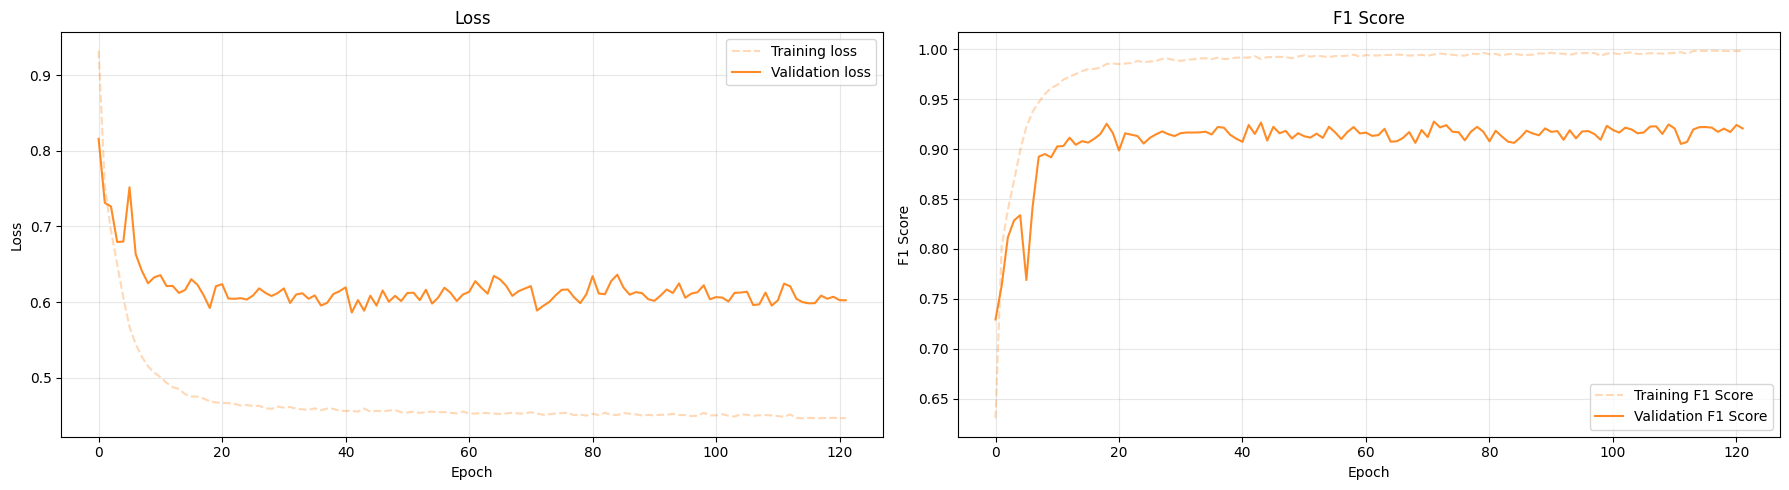

In [ ]:
from src.training.metrics import plot_training_history

# Plot training history
plot_training_history(
    history,
    task=config['model']['task'],
    save_path=None
)

## 12. Model Evaluation


MODEL EVALUATION

Validation Metrics:
Accuracy:  0.9229
Precision: 0.9198
Recall:    0.9229
F1 Score:  0.9208


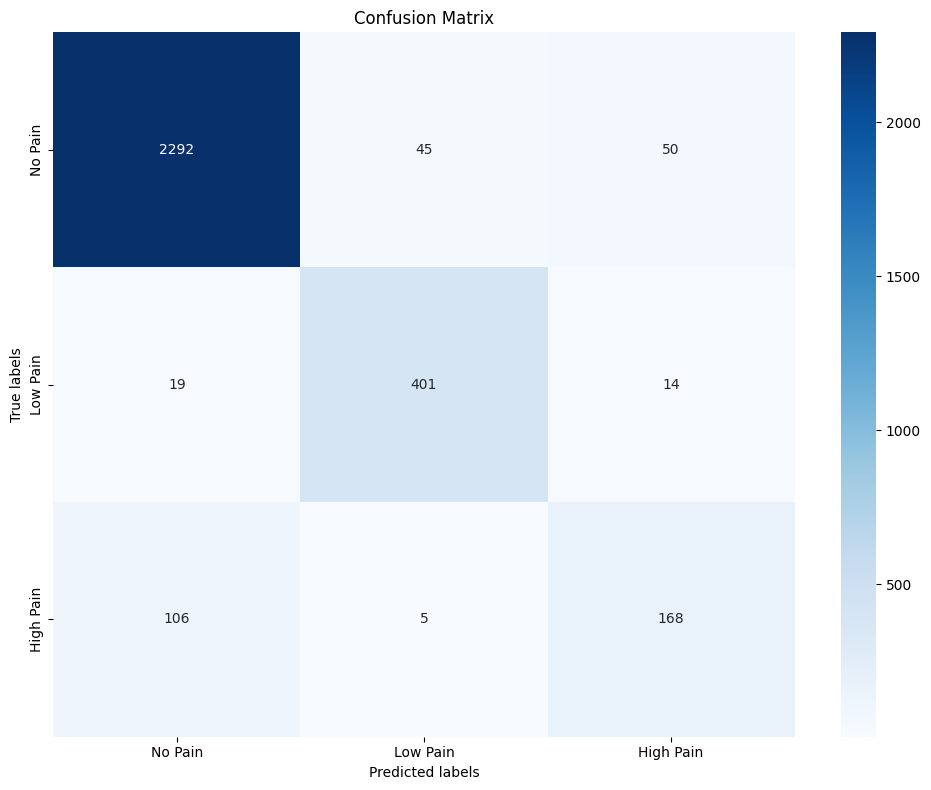

In [ ]:
from src.evaluation.evaluate import evaluate_and_report

# Define class names for better visualization
class_names = ['No Pain', 'Low Pain', 'High Pain']

print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

# Evaluate on validation set
val_metrics = evaluate_and_report(
    model=model,
    data_loader=val_loader,
    device=device,
    dataset_name="Validation",
    task=config['model']['task'],
    class_names=class_names,
    plot_cm=True
)

print("="*80)


In [ ]:
from src.evaluation.evaluate import evaluate_model
from sklearn.metrics import classification_report
import torch
import numpy as np
from tqdm.auto import tqdm # Used for a progress bar, optional

model.eval()
model.to(device) 


preds, targets = evaluate_model(model, val_loader, device, config['model']['task'])

print("\n" + "="*80)
print("DETAILED PER-CLASS EVALUATION")
print("="*80)

class_names = ['No Pain', 'Low Pain', 'High Pain']

# Generate the report
report = classification_report(
    y_true=targets, 
    y_pred=preds, 
    target_names=class_names, 
    digits=4,
    zero_division=0
)

print(report)
print("="*80)


DETAILED PER-CLASS EVALUATION
              precision    recall  f1-score   support

     No Pain     0.9483    0.9602    0.9542      2387
    Low Pain     0.8891    0.9240    0.9062       434
   High Pain     0.7241    0.6022    0.6575       279

    accuracy                         0.9229      3100
   macro avg     0.8539    0.8288    0.8393      3100
weighted avg     0.9198    0.9229    0.9208      3100



## 12.a. Cross-Validation (Optional)

Perform K-fold cross-validation if enabled in config.

In [ ]:
if config['cross_validation']['enabled']:
    from src.training.cross_validation import k_fold_cross_validation, plot_cv_results
    from src.models.rnn_models import RecurrentNet
    
    print("\n" + "="*80)
    print("CROSS-VALIDATION")
    print("="*80)
    print(f"K-folds: {config['cross_validation']['k_folds']}")
    print(f"Using entire training set (before train/val split)")
    print()
    
    # Prepare base model parameters
    base_model_params = {
        'input_size': config['model']['input_size'],
        'hidden_size': config['model']['hidden_size'],
        'num_layers': config['model']['num_layers'],
        'num_classes': config['model']['num_classes'],
        'rnn_type': config['model']['rnn_type'],
        'bidirectional': config['model']['bidirectional'],
        'dropout_rate': config['model']['dropout_rate'],
        'task': config['model']['task']
    }
    
    # Prepare base trainer parameters
    base_trainer_params = {
        'epochs': config['training']['epochs'],
        'batch_size': config['training']['batch_size'],
        'learning_rate': config['training']['learning_rate'],
        'weight_decay': config['training']['l2_lambda'],
        'patience': config['training']['patience'],
        'device': device,
        'optimizer': 'AdamW',
        'verbose': config['training']['verbose']
    }
    
    # Run K-fold cross-validation
    fold_losses, fold_metrics, best_scores = k_fold_cross_validation(
        X=X_train_seq,
        y=y_train_seq,
        model_class=RecurrentNet,
        base_model_params=base_model_params,
        base_trainer_params=base_trainer_params,
        k=config['cross_validation']['k_folds'],
        seed=config['seed'],
        use_class_weights=True,
        verbose=True
    )
    
    print("\n" + "="*80)
    print("📊 CROSS-VALIDATION SUMMARY")
    print("="*80)
    print(f"Mean F1: {best_scores['mean']:.4f} ± {best_scores['std']:.4f}")
    print(f"Min F1:  {min([best_scores[f'fold_{i}'] for i in range(config['cross_validation']['k_folds'])]):.4f}")
    print(f"Max F1:  {max([best_scores[f'fold_{i}'] for i in range(config['cross_validation']['k_folds'])]):.4f}")
    print("="*80)
    
    # Visualize results
    plot_cv_results(fold_metrics, k=config['cross_validation']['k_folds'])
else:
    print("\n⚠️  Cross-validation disabled in config")
    print("   Set cross_validation.enabled=True to run K-fold cross-validation")



⚠️  Cross-validation disabled in config
   Set cross_validation.enabled=True to run K-fold cross-validation


## 12.b. Hyperparameter Tuning (Optional)

Perform grid search over hyperparameters if enabled in config.

In [ ]:
if config['hyperparameter_tuning']['enabled']:
    from src.training.cross_validation import grid_search_hyperparameters, plot_grid_search_results
    from src.models.rnn_models import RecurrentNet
    
    print("\n" + "="*80)
    print("HYPERPARAMETER TUNING")
    print("="*80)
    print("⚠️  WARNING: This is very time-consuming!")
    print("\nParameter Grid:")
    for param, values in config['hyperparameter_tuning']['param_grid'].items():
        print(f"  {param}: {values}")
    
    # Calculate total combinations
    param_grid = config['hyperparameter_tuning']['param_grid']
    total_combinations = 1
    for values in param_grid.values():
        total_combinations *= len(values)
    
    print(f"\nTotal combinations: {total_combinations}")
    print(f"Total training runs: {total_combinations * 5} (with 5-fold CV)")
    print()
    
    # Ask for confirmation
    proceed = input("Proceed with hyperparameter tuning? (yes/no): ").lower().strip()
    
    if proceed == 'yes':
        # Prepare base model parameters
        base_model_params = {
            'input_size': config['model']['input_size'],
            'num_classes': config['model']['num_classes'],
            'rnn_type': config['model']['rnn_type'],
            'bidirectional': config['model']['bidirectional'],
            'task': config['model']['task']
        }
        
        # Prepare base trainer parameters (add save_dir to save in models/tuning)
        base_trainer_params = {
            'epochs': config['training']['epochs'],
            'batch_size': config['training']['batch_size'],
            'weight_decay': config['training']['l2_lambda'],
            'patience': config['training']['patience'],
            'device': device,
            'optimizer': config['training']['optimizer'],
            'verbose': 10,
            'save_dir': config['logging']['save_dir']  # Save tuning models to configured directory
        }
        
        # Run grid search with cross-validation
        all_results, best_params, best_score = grid_search_hyperparameters(
            X=X_train_seq,
            y=y_train_seq,
            model_class=RecurrentNet,
            param_grid=param_grid,
            base_model_params=base_model_params,
            base_trainer_params=base_trainer_params,
            cv_k=5,
            cv_seed=config['seed'],
            use_class_weights=True,
            verbose=True
        )
        
        print("\n" + "="*80)
        print("🏆 HYPERPARAMETER TUNING RESULTS")
        print("="*80)
        print(f"Best Mean F1 Score: {best_score:.4f}")
        print("\nBest Parameters:")
        for param, value in best_params.items():
            print(f"  {param}: {value}")
        print("="*80)
        
        # Visualize results
        plot_grid_search_results(all_results, top_n=min(10, len(all_results)))
        
        print("\n💡 To use these parameters, update your config file with the best values above")
    else:
        print("❌ Hyperparameter tuning cancelled")
else:
    print("\n⚠️  Hyperparameter tuning disabled in config")
    print("   Set hyperparameter_tuning.enabled=True to run grid search")
    print("   WARNING: This is very time-consuming!")



⚠️  Hyperparameter tuning disabled in config
   Set hyperparameter_tuning.enabled=True to run grid search


## 13. Save Final Results

In [ ]:
import json

print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Create save directory
os.makedirs(config['logging']['save_dir'], exist_ok=True)

# Get final F1 score for filename
final_f1 = val_metrics.get('f1', 0.0)

# Generate descriptive results filename including F1 score
results_name = generate_experiment_name(config, f1_score=final_f1)
print(f"Results file: {results_name}_results.json")

# Save final results
results = {
    'experiment_name': experiment_name,
    'config': config,
    'val_metrics': val_metrics,
    'model_architecture': str(model),
    'total_parameters': sum(p.numel() for p in model.parameters())
}

results_path = os.path.join(config['logging']['save_dir'], f'{results_name}_results.json')
with open(results_path, 'w') as f:
    # Convert numpy types to native Python types for JSON serialization
    json_results = {}
    for key, value in results.items():
        if key == 'val_metrics':
            json_results[key] = {k: float(v) if isinstance(v, np.number) else v for k, v in value.items()}
        elif key == 'config':
            json_results[key] = value
        else:
            json_results[key] = value
    json.dump(json_results, f, indent=2)

print(f"✓ Results saved to: {results_path}")

# Close TensorBoard writer
writer.close()
print(f"✓ TensorBoard logs saved")

print("\n" + "="*80)
print("✅ ALL DONE!")
print("="*80)
print(f"\nTo view TensorBoard logs, run:")
print(f"  tensorboard --logdir {config['logging']['tensorboard_dir']}")
print("="*80)


SAVING RESULTS
Results file: LSTM_bi_256h_1l_0.0003lr_d020_20251113_113531_f109208_results.json
✓ Results saved to: ./models/LSTM_bi_256h_1l_0.0003lr_d020_20251113_113531_f109208_results.json
✓ TensorBoard logs saved

✅ ALL DONE!

To view TensorBoard logs, run:
  tensorboard --logdir ./tensorboard


## 14. Generate Submission

Preprocess test data and generate predictions for submission.

In [ ]:
print("\n" + "="*80)
print("GENERATING SUBMISSION")
print("="*80)

# Step 1: Preprocess test data (same as training data)
print("\n📋 Step 1: Preprocessing test data...")

# Load raw test data (already loaded in cell 2, but reload to be sure)
X_test_raw = pd.read_csv(os.path.join(data_config['raw_dir'], data_config['test_file']))
print(f"  Raw test data: {X_test_raw.shape}")

# Apply same preprocessing as training data (without labels)
from src.preprocessing.utils import preprocess_pirates_data

# Create dummy labels for preprocessing (will be ignored)
dummy_labels = pd.DataFrame({
    'sample_index': X_test_raw['sample_index'].unique(),
    'label': 'no_pain'  # Dummy label
})

X_test_processed, _ = preprocess_pirates_data(X_test_raw, dummy_labels, config, verbose=False)
print(f"  Preprocessed test data: {X_test_processed.shape}")

# Step 2: Normalize test data using TRAINING statistics
print("\n📐 Step 2: Normalizing test data using training statistics...")

# CRITICAL: Use the scaler that was fitted during training (Cell 10)
# This ensures test data is normalized with the SAME statistics as training data
# Prevents data leakage and ensures consistency

# Verify scaler exists
if 'scaler' not in locals():
    print("  ⚠️  WARNING: Scaler not found! Re-fitting on training data...")
    print("     This should only happen if you're running this cell independently.")
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    scaler.fit(X_train_split[feature_columns])

# Get feature columns (same as training)
feature_columns_test = feature_columns

# Normalize test data using TRAINING statistics (NOT test statistics!)
X_test_norm = X_test_processed.copy()
X_test_norm[feature_columns_test] = scaler.transform(X_test_processed[feature_columns_test])

print(f"  ✓ Test data normalized using scaler from Cell 10 (training statistics)")
print(f"  Test range: [{X_test_norm[feature_columns_test].min().min():.4f}, {X_test_norm[feature_columns_test].max().max():.4f}]")
print(f"  Training was normalized to: [0.0000, 1.0000]")

# Step 3: Build sequences
print("\n🔄 Step 3: Building sequences...")

# Convert to float32
X_test_norm[feature_columns_test] = X_test_norm[feature_columns_test].astype(np.float32)

# Build sequences (no labels needed, just features)
from src.preprocessing.utils import build_sequences

# Create a temporary dataframe with dummy labels for sequence building
df_test = X_test_norm.copy()
df_test['label'] = 0  # Dummy label for sequence building

X_test_seq, _ = build_sequences(
    df_test,
    window=config['sequences']['window_size'],
    stride=config['sequences']['stride'],  # Use same stride as training
    feature_columns=feature_columns_test
)

print(f"  Test sequences: {X_test_seq.shape} (samples, timesteps, features)")
print(f"  Unique test samples: {X_test_processed['sample_index'].nunique()}")

# Step 4: Make predictions
print("\n🤖 Step 4: Making predictions with trained model...")

model.eval()
all_predictions = []

# Create test dataloader
from torch.utils.data import TensorDataset, DataLoader
test_dataset = TensorDataset(torch.from_numpy(X_test_seq).float())
test_dataloader = DataLoader(
    test_dataset, 
    batch_size=config['training']['batch_size'], 
    shuffle=False,
    num_workers=0
)

with torch.no_grad():
    for (inputs,) in test_dataloader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predictions = outputs.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())

all_predictions = np.concatenate(all_predictions)

# Map predictions back to labels
label_mapping = {0: 'no_pain', 1: 'low_pain', 2: 'high_pain'}
predicted_labels = [label_mapping[pred] for pred in all_predictions]

print(f"  Total predictions: {len(predicted_labels)}")
print(f"  Prediction distribution:")
unique, counts = np.unique(all_predictions, return_counts=True)
for label_id, count in zip(unique, counts):
    print(f"    {label_mapping[label_id]}: {count} ({count/len(all_predictions)*100:.2f}%)")

# Step 5: Create submission DataFrame
print("\n📝 Step 5: Creating submission file...")

# Get unique sample indices from test data
# Note: With stride < window_size, we have multiple predictions per sample
# We need to aggregate them (use majority vote or first prediction)

# Build a mapping from sequence index to sample_index
sample_indices = []
for sample_id in X_test_processed['sample_index'].unique():
    sample_data = X_test_processed[X_test_processed['sample_index'] == sample_id]
    num_sequences = max(1, (len(sample_data) - config['sequences']['window_size']) // config['sequences']['stride'] + 1)
    sample_indices.extend([sample_id] * num_sequences)

# Create DataFrame with predictions
submission_df = pd.DataFrame({
    'sample_index': sample_indices,
    'label': predicted_labels
})

# If we have multiple predictions per sample (due to stride), aggregate them
if config['sequences']['stride'] < config['sequences']['window_size']:
    print(f"  ⚠️  Multiple predictions per sample detected (stride < window_size)")
    print(f"     Using majority vote to aggregate predictions...")
    
    # Majority vote per sample
    submission_df = submission_df.groupby('sample_index')['label'].agg(
        lambda x: x.value_counts().index[0]  # Most common prediction
    ).reset_index()

# Ensure we have predictions for all test samples
expected_samples = X_test_raw['sample_index'].nunique()
actual_samples = len(submission_df)

print(f"  Expected samples: {expected_samples}")
print(f"  Actual predictions: {actual_samples}")

if actual_samples != expected_samples:
    print(f"  ⚠️  WARNING: Sample count mismatch!")
else:
    print(f"  ✓ Sample count matches!")

# Save submission file
submission_path = os.path.join(config['logging']['save_dir'], f'{experiment_name}_submission.csv')
submission_df.to_csv(submission_path, index=False)

print(f"\n✅ Submission file saved to: {submission_path}")
print(f"   Shape: {submission_df.shape}")
print(f"\n📊 Submission Summary:")
print(submission_df['label'].value_counts().sort_index())

print("="*80)
print("\n💡 TIP: You can now submit this CSV file to the competition platform!")
print("="*80)



GENERATING SUBMISSION

📋 Step 1: Preprocessing test data...
  Raw test data: (211840, 40)
  Preprocessed test data: (211840, 34)

📐 Step 2: Normalizing test data using training statistics...
  ✓ Test data normalized using scaler from Cell 10 (training statistics)
  Test range: [-0.0722, 1.4598]
  Training was normalized to: [0.0000, 1.0000]

🔄 Step 3: Building sequences...
Built 41044 sequences from 1324 users
Sequence shape: (41044, 10, 31)
  Test sequences: (41044, 10, 31) (samples, timesteps, features)
  Unique test samples: 1324

🤖 Step 4: Making predictions with trained model...
  Total predictions: 41044
  Prediction distribution:
    no_pain: 31306 (76.27%)
    low_pain: 5993 (14.60%)
    high_pain: 3745 (9.12%)

📝 Step 5: Creating submission file...
  ⚠️  Multiple predictions per sample detected (stride < window_size)
     Using majority vote to aggregate predictions...
  Expected samples: 1324
  Actual predictions: 1324
  ✓ Sample count matches!

✅ Submission file saved to: .